# Bayesian Optimization Basics with GPyTorch and BoTorch

_Drew Gjerstad_

**Includes content adapted from Professor Aryan Deshwal's special topics course on AI for sequential decision making at the University of Minnesota (Spring 2026).**

In this notebook, we illustrate how a Bayesian optimization problem can be implemented and optimized in Python using three main Python libraries: PyTorch, GPyTorch, and BoTorch. We also review the primitives involved in every Bayesian optimization problem as they relate to our implementation.

Here, we aim to optimize the six-dimensional Hartmann objective function. You can read more about this common synthetic objective [here](https://www.sfu.ca/~ssurjano/hart6.html).

## Load Dependencies

In [24]:
import torch
from botorch import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.acquisition import LogExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.test_functions import Hartmann
from botorch.models.transforms import Normalize, Standardize
from gpytorch.mlls import ExactMarginalLogLikelihood
import matplotlib.pyplot as plt
import numpy as np

torch.set_default_dtype(torch.float64)

## Define the Objective Function
The first step in formulating a Bayesian optimization problem is defining the objective function, the function we aim to optimize. In this notebook, we aim to minimize the 6D Hartmann function for illustration purposes. However, in more practical settings such as drug discovery, materials discovery, or AutoML, the objective function often represents the promise of a particular optimizer. Note that in many cases we do not have access to a closed form expression of the objective function which gives rise to **black-box optimization**.

In [10]:
# Define objective function
neg_hartmann6 = Hartmann(dim=6, negate=True)

## Define Initial Dataset
Before we start any Bayesian optimization loop, we must have an initial dataset that will serve as the "starting point" of the optimization process.

In [11]:
# Define initial dataset
N_START = 10
DIM = 6

train_x = torch.rand(N_START, DIM)
train_y = neg_hartmann6(train_x).unsqueeze(-1)

## Fit Surrogate (GP) Model
We must also fit a surrogate model on the initial dataset such that we can make prediction (estimates) and quantify uncertainty during the optimization process.

In [12]:
# Fit surrogate model
model = SingleTaskGP(train_x, train_y)
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)

ExactMarginalLogLikelihood(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (noise_prior): LogNormalPrior()
      (raw_noise_constraint): GreaterThan(1.000E-04)
    )
  )
  (model): SingleTaskGP(
    (likelihood): GaussianLikelihood(
      (noise_covar): HomoskedasticNoise(
        (noise_prior): LogNormalPrior()
        (raw_noise_constraint): GreaterThan(1.000E-04)
      )
    )
    (mean_module): ConstantMean()
    (covar_module): RBFKernel(
      (lengthscale_prior): LogNormalPrior()
      (raw_lengthscale_constraint): GreaterThan(2.500E-02)
    )
    (outcome_transform): Standardize()
  )
)

We can also inspect the initial parameters of the model.

In [13]:
# Inspect model parameters
for n, v in model.named_parameters():
    print(n, v)

likelihood.noise_covar.raw_noise Parameter containing:
tensor([0.0065], requires_grad=True)
mean_module.raw_constant Parameter containing:
tensor(0.0586, requires_grad=True)
covar_module.raw_lengthscale Parameter containing:
tensor([[1.1373, 1.6473, 1.1518, 0.1353, 0.6580, 1.4600]], requires_grad=True)


## Optimize the Acquisition Function
Another key component to the Bayesian optimization loop is the acquisition function and its subsequent optimization. The acquisition function serves as the "decision maker" with respect to where we will sample (observe) next. We optimize this function to achieve an optimal acquisition policy that enables us to make "good" progress during the Bayesian optimization loop.

In [20]:
# Define the acquisition function
best_value = train_y.max()
EI = LogExpectedImprovement(model, best_f=best_value)

Note that above we use the logarithmic version of Expected Improvement (EI) due to unideal behavior that occurs with the standard version of EI.

In [21]:
# Optimize the acquisition function
new_point_analytic, _ = optimize_acqf(
    acq_function=EI,                                # AF to optimize
    bounds=torch.tensor([[0.0] * 6, [1.0] * 6]),    # input space domain
    q=1,                                            # number of candidates
    num_restarts=20,                                # number of restarts
    raw_samples=100,                                # number of init points
    options={}                                      # options (see docs)
)

train_x = torch.cat([train_x, new_point_analytic])
train_y = neg_hartmann6(train_x).unsqueeze(-1)

## Full Bayesian Optimization Loop
With each of our primitives (surrogate model, acquisition function, acquisition function optimizer) defined, we can now implement the full Bayesian optimization loop to minimize the Hartmann function. Effectively, we wrap the previous set of steps in a loop that iterates over a defined number of optimization "steps".

In [23]:
# BO loop
for _ in range(50):
    # Define model, marginal log-likelihood
    model = SingleTaskGP(train_x, train_y, input_transform=Normalize(d=DIM),
                         outcome_transform=Standardize(m=1))
    mll = ExactMarginalLogLikelihood(model.likelihood, model)

    # Fit GP model
    fit_gpytorch_mll(mll)

    # Obtain best value (so far)
    best_value = train_y.max()

    # Define acquisition function
    EI = LogExpectedImprovement(model=model, best_f=best_value)

    # Acquire new observation (optimize the acquisition function)
    new_point_analytic, _ = optimize_acqf(
        acq_function=EI,                                # AF to optimize
        bounds=torch.tensor([[0.0] * 6, [1.0] * 6]),    # input space domain
        q=1,                                            # number of candidates
        num_restarts=20,                                # number of restarts
        raw_samples=100,                                # number of init points
        options={}                                      # options (see docs)
    )

    # Add new observation to dataset (and corresponding objective value)
    train_x = torch.cat([train_x, new_point_analytic])
    train_y = neg_hartmann6(train_x).unsqueeze(-1)

    # Report progress
    print(f"Best value achieved after {len(train_x) - N_START}: {train_y.max().item()}")

Best value achieved after 3: 2.404643742229635
Best value achieved after 4: 2.404643742229635
Best value achieved after 5: 2.404643742229635
Best value achieved after 6: 2.404643742229635
Best value achieved after 7: 2.404643742229635
Best value achieved after 8: 2.404643742229635
Best value achieved after 9: 2.5005845309200034
Best value achieved after 10: 2.632088421322403
Best value achieved after 11: 2.632088421322403
Best value achieved after 12: 2.816792130933426
Best value achieved after 13: 2.816792130933426
Best value achieved after 14: 2.816792130933426
Best value achieved after 15: 2.816792130933426
Best value achieved after 16: 2.816792130933426
Best value achieved after 17: 2.816792130933426
Best value achieved after 18: 2.816792130933426
Best value achieved after 19: 3.1550724075272516
Best value achieved after 20: 3.1550724075272516
Best value achieved after 21: 3.1550724075272516
Best value achieved after 22: 3.1550724075272516
Best value achieved after 23: 3.1550724075

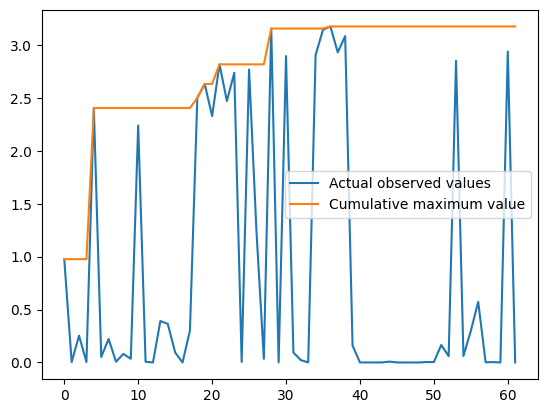

In [25]:
# Plot optimization progress
plt.plot(train_y.numpy(), label='Actual observed values')
plt.plot(np.maximum.accumulate(train_y.numpy()), label='Cumulative maximum value')
plt.legend()
plt.show()